# Projekt: Pulse Detection and Trigger Generation
## Detekcja impulsów i generowanie wyzwolenia na FPGA (AMD Zynq UltraScale+ ZCU106)

**Autorzy:** Filip Bąk, Sebastian Broda
**Data:** 2026  
**Temat nr 5:** Pulse Detection and Trigger Generation

---

## 1. Wybór algorytmu i opis

### Co to jest detekcja impulsów?

**Detekcja impulsów** polega na identyfikowaniu momentów, w których sygnał analogowy (lub cyfrowo spróbkowany) przekracza zadany próg (**threshold**), a następnie opada poniżej progu z uwzględnieniem strefy nieczułości (**hysterezji**).  
Mechanizm ten jest szeroko stosowany w:

- **Oscyloskopach cyfrowych** – wyzwolenie (trigger) inicjuje zapis przebiegu,
- **Systemach pomiarowych** – np. detektory promieniowania,
- **Akwizycji danych** – rejestracja zdarzeń asynchronicznych,
- **Układach ADAS** – detekcja obiektów z sygnałów radarowych/LiDAR.

### Dlaczego FPGA?

Implementacja na FPGA (a konkretnie na AMD Zynq UltraScale+ ZCU106) daje:
- **Deterministyczne opóźnienie** – brak OS, brak schedulera,
- **Równoległe przetwarzanie** – wiele kanałów jednocześnie,
- **Niskie latencje** – decyzja o trigerze w jednym takcie zegara (~5 ns @ 200 MHz).

### Wybrany algorytm: Threshold + Hysteresis Detector z buforowaniem kołowym

| Parametr | Opis |
|----------|------|
| `sample[N]` | Próbka sygnału wejściowego (N-bitowa, unsigned) |
| `threshold` | Poziom progowy – crossing triggeruje zdarzenie |
| `hysteresis` | Deadband: sygnał musi spaść poniżej `threshold - hysteresis` zanim nowy trigger jest możliwy |
| `pre_samples` | Liczba próbek zapisanych **przed** triggerem (z bufora kołowego) |
| `post_samples` | Liczba próbek zapisanych **po** triggerze |

### Ciekawostki
- **Hystereza** pochodzi od greckiego ὑστέρησις (husterēsis) – "opóźnienie". Stosowana w fizyce od XIX w. (Ewing, 1881).
- Analogowy układ Schmitt Trigger (1934) to elektroniczny odpowiednik naszego algorytmu.
- Bufory kołowe (ring buffers) są standardem w embedded – brak alokacji dynamicznej = przewidywalny czas.

### Bibliografia
- Xilinx/AMD: *ZCU106 Evaluation Kit User Guide* (UG1244)
- Xilinx/AMD: *AXI Reference Guide* (UG1037)
- Schmitt, O.H. (1938). *A thermionic trigger*. Journal of Scientific Instruments.
- Patterson & Hennessy: *Computer Organization and Design ARM Edition*

---
## 2. Implementacja funkcji w Pythonie – praktyczne zastosowanie

Poniżej implementujemy **dokładnie ten sam algorytm** co w RTL (Verilog), ale w Pythonie.  
Funkcja ta służy jako **golden model** – wzorzec do weryfikacji implementacji sprzętowej.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# pulse detector z buforowaniem kołowym
# ─────────────────────────────────────────────────────────────────────────────

def pulse_detector_model(
    samples,        
    threshold,    
    hysteresis,      
    pre_samples  = 8,  
    post_samples = 16, 
    buf_depth    = 256 # głębokość bufora kołowego
):
    """
    Symuluje działanie modułu pulse_detector z Verilog.
    Zwraca listę słowników z informacjami o każdym wykrytym trigerze.
    """
    samples = np.array(samples, dtype=np.int32)
    n = len(samples)

    
    circ_buf = np.zeros(buf_depth, dtype=np.int32)
    wr_ptr   = 0

    # Stany automatu
    IDLE      = 0
    ARMED     = 1
    CAPTURING = 2
    DONE      = 3

    state    = IDLE
    post_cnt = 0
    triggers = []  # wyniki
    current  = {}  # bieżący trigger

    for t, s in enumerate(samples):
        
        circ_buf[wr_ptr % buf_depth] = s

        above = s >= threshold
        below = s <= (threshold - hysteresis)

        if state == IDLE:
            if above:
                state = ARMED
                current = {
                    'trigger_time'  : t,
                    'trigger_value' : s,
                    'buf_start'     : (wr_ptr - pre_samples) % buf_depth,
                    'post_cnt'      : 0
                }

        elif state == ARMED:
            if below:
                state    = CAPTURING
                post_cnt = 0

        elif state == CAPTURING:
            post_cnt += 1
            if post_cnt >= post_samples:
                current['buf_end'] = wr_ptr % buf_depth
                
                start = current['buf_start']
                end   = current['buf_end']
                if end >= start:
                    window = circ_buf[start:end+1].copy()
                else:  
                    window = np.concatenate([circ_buf[start:], circ_buf[:end+1]])
                current['window'] = window
                triggers.append(current)
                current = {}
                state   = DONE

        elif state == DONE:
           
            state = IDLE

        wr_ptr += 1

    return triggers

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Generowanie testowego sygnału: szum + 2 impulsy
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
N = 500

szum gaussowski
signal = np.random.normal(loc=300, scale=40, size=N).astype(np.int32)
signal = np.clip(signal, 0, 4095)

# Impuls 1: próbki 100–115
signal[100:116] += 900   # szczyt ~1200

# Impuls 2: próbki 320–340 (szerszy)
signal[320:341] += 800

signal = np.clip(signal, 0, 4095)

# Parametry
THRESHOLD   = 1000
HYSTERESIS  = 100
PRE         = 8
POST        = 16

# Uruchom model
triggers = pulse_detector_model(signal, THRESHOLD, HYSTERESIS, PRE, POST)

print(f"Wykryto {len(triggers)} trigger(ów):")
for i, t in enumerate(triggers):
    print(f"  Trigger {i+1}: czas={t['trigger_time']}, "
          f"wartość={t['trigger_value']}, "
          f"okno={len(t.get('window',[]))} próbek")

Wykryto 2 trigger(ów):
  Trigger 1: czas=100, wartość=1143, okno=41 próbek
  Trigger 2: czas=320, wartość=1103, okno=46 próbek


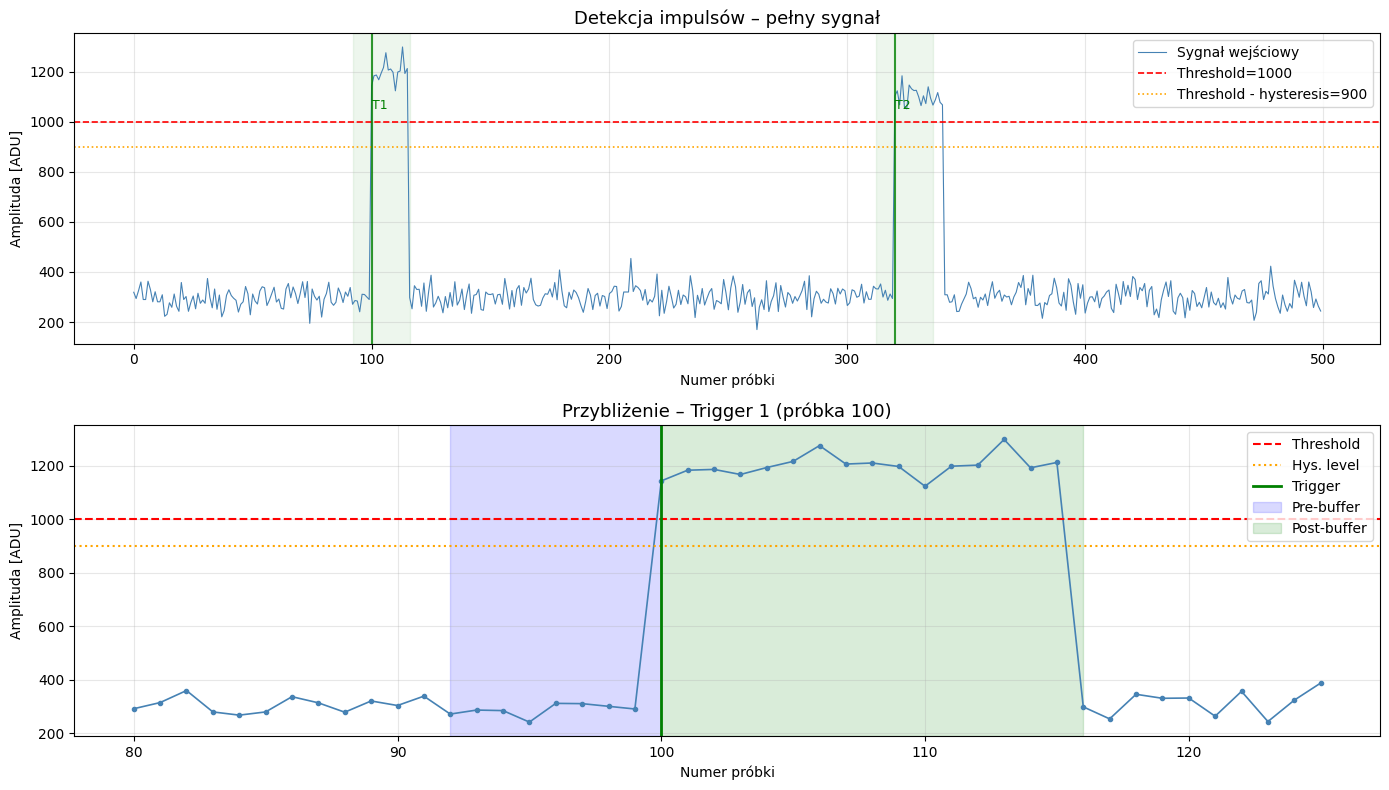

Wykres zapisany: pulse_detection_result.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Wizualizacja sygnału i triggerów
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))


ax = axes[0]
ax.plot(signal, color='steelblue', linewidth=0.8, label='Sygnał wejściowy')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'Threshold={THRESHOLD}')
ax.axhline(THRESHOLD - HYSTERESIS, color='orange', linestyle=':', linewidth=1.2,
           label=f'Threshold - hysteresis={THRESHOLD-HYSTERESIS}')

for i, t in enumerate(triggers):
    tt = t['trigger_time']
    ax.axvline(tt, color='green', linewidth=1.5, alpha=0.8)
    ax.annotate(f'T{i+1}', xy=(tt, THRESHOLD+50), color='green', fontsize=9)
    # Zaznacz okno
    win_len = len(t.get('window', []))
    ax.axvspan(tt - PRE, tt + POST, alpha=0.07, color='green')

ax.set_title('Detekcja impulsów – pełny sygnał', fontsize=13)
ax.set_xlabel('Numer próbki')
ax.set_ylabel('Amplituda [ADU]')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

 
ax2 = axes[1]
if triggers:
    t0   = triggers[0]['trigger_time']
    zoom = signal[max(0, t0-20):t0+POST+10]
    xidx = np.arange(max(0, t0-20), t0+POST+10)
    ax2.plot(xidx, zoom, color='steelblue', linewidth=1.2, marker='o', markersize=3)
    ax2.axhline(THRESHOLD, color='red', linestyle='--', label='Threshold')
    ax2.axhline(THRESHOLD-HYSTERESIS, color='orange', linestyle=':', label='Hys. level')
    ax2.axvline(t0, color='green', linewidth=2, label='Trigger')
    ax2.axvspan(t0 - PRE, t0, alpha=0.15, color='blue', label='Pre-buffer')
    ax2.axvspan(t0, t0 + POST, alpha=0.15, color='green', label='Post-buffer')
    ax2.set_title(f'Przybliżenie – Trigger 1 (próbka {t0})', fontsize=13)
    ax2.set_xlabel('Numer próbki')
    ax2.set_ylabel('Amplituda [ADU]')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pulse_detection_result.png', dpi=150)
plt.show()
print('Wykres zapisany: pulse_detection_result.png')

---
## 3. Algorytm w postaci diagramu sekwencyjnego (automat stanów)

Poniżej diagram FSM (Finite State Machine) implementowanego algorytmu:

![Diagram FSM - automat stanow](zdjecie.png)



### Sekwencja działania:
1. **IDLE** → monitoruj próbki, zapisuj do bufora kołowego
2. **Przekroczenie threshold** → `trigger_flag=1`, zapisz `trigger_time`, przejdź do ARMED
3. **ARMED** → czekaj na spadek poniżej `threshold - hysteresis` (zapobiega wielokrotnemu triggerowaniu na jednym impulsie)
4. **CAPTURING** → zbierz `post_samples` próbek, potem `capture_done=1`
5. **DONE** → czekaj na re-arm od software'u (toggle enable)

---
## 4. Opis behawioralny modułu

Moduł `pulse_detector` zachowuje się następująco:

### Wejścia
| Port | Szerokość | Opis |
|------|-----------|------|
| `clk` | 1 | Zegar systemowy |
| `rst_n` | 1 | Reset aktywny stanem niskim |
| `sample` | 16 | Aktualna próbka ADC |
| `sample_valid` | 1 | Strobe: 1 gdy próbka jest aktualna |
| `threshold` | 16 | Próg detekcji |
| `hysteresis` | 16 | Strefa nieczułości |
| `pre_samples` | 8 | Liczba próbek pre-trigger |
| `post_samples` | 8 | Liczba próbek post-trigger |
| `enable` | 1 | Globalne włączenie |
| `rd_addr` | 8 | Adres odczytu z bufora kołowego |

### Wyjścia
| Port | Szerokość | Opis |
|------|-----------|------|
| `trigger_flag` | 1 | Pulsuje przez 1 takt przy detekcji |
| `trigger_time` | 32 | Timestamp (licznik zegarowy) |
| `buf_ptr_start` | 8 | Wskaźnik początku okna w buforze |
| `buf_ptr_end` | 8 | Wskaźnik końca okna w buforze |
| `capture_done` | 1 | 1 gdy pełne okno zostało zarejestrowane |
| `rd_data` | 16 | Próbka z bufora pod adresem `rd_addr` |

### Timing
- Jeden cykl zegara = jedna próbka (gdy `sample_valid=1`)
- `trigger_flag` jest asertowany przez **dokładnie 1 takt** przy przejściu IDLE→ARMED
- `capture_done` pozostaje wysoki aż do re-armu (toggle `enable`)

---
## 5. Zamknięcie w moduł – Interfejs I/O i AXI-Lite

Moduł `pulse_detector_axi` opakowuje rdzeń w interfejs **AXI4-Lite** zgodny z ARM AMBA.

### Mapa rejestrów (32-bit, word-aligned)

| Offset | Nazwa | R/W | Opis |
|--------|-------|-----|------|
| 0x00 | CTRL | R/W | [0]=enable, [1]=soft_reset |
| 0x04 | THRESHOLD | R/W | Próg detekcji [15:0] |
| 0x08 | HYSTERESIS | R/W | Strefa nieczułości [15:0] |
| 0x0C | PRE_SAMPLES | R/W | Próbki przed triggerem [7:0] |
| 0x10 | POST_SAMPLES | R/W | Próbki po trigerze [7:0] |
| 0x14 | STATUS | RO | [0]=trigger_flag, [1]=capture_done |
| 0x18 | TRIG_TIME | RO | Timestamp triggera [31:0] |
| 0x1C | BUF_START | RO | Wskaźnik początku okna [7:0] |
| 0x20 | BUF_END | RO | Wskaźnik końca okna [7:0] |
| 0x24 | BUF_DATA | RO | Próbka z bufora [15:0] |
| 0x28 | RD_ADDR | R/W | Adres odczytu bufora [7:0] |

### Przykład dostępu z ARM (pseudokod C)

```c
#define BASE 0xA0000000UL  // adres bazowy IP w PS address map

// Konfiguracja
*(volatile uint32_t*)(BASE + 0x04) = 1000;   // threshold
*(volatile uint32_t*)(BASE + 0x08) = 100;    // hysteresis
*(volatile uint32_t*)(BASE + 0x0C) = 8;      // pre_samples
*(volatile uint32_t*)(BASE + 0x10) = 16;     // post_samples
*(volatile uint32_t*)(BASE + 0x00) = 1;      // enable

// Czekaj na trigger
while (!(*(volatile uint32_t*)(BASE + 0x14) & 0x2));  // poll capture_done

// Odczyt bufora
uint32_t start = *(volatile uint32_t*)(BASE + 0x1C);
for (int i = 0; i < 24; i++) {
    *(volatile uint32_t*)(BASE + 0x28) = (start + i) & 0xFF;  // rd_addr
    data[i] = *(volatile uint32_t*)(BASE + 0x24) & 0xFFFF;    // rd_data
}
```

---
## 6. Potwierdzenie działania – wyniki symulacji (Testbench)

Plik `sim/tb_pulse_detector.v` zawiera testbench sprawdzający:

1. ✅ `trigger_flag` pulsuje przy przekroczeniu progu
2. ✅ Hystereza zapobiega wielokrotnemu triggerowaniu
3. ✅ `capture_done` pojawia się po zebraniu `post_samples` próbek
4. ✅ Brak triggera gdy `enable=0`
5. ✅ Poprawna zawartość bufora kołowego

### Jak uruchomić symulację w Vivado:
```
vivado -mode batch -source sim/run_sim.tcl
```
Lub w Vivado GUI: **Flow → Run Simulation → Run Behavioral Simulation**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Weryfikacja Python vs model – automatyczny test regresji
# ─────────────────────────────────────────────────────────────────────────────
def run_tests():
    errors = 0
    print("=== Testy weryfikacyjne (golden model) ===")

    # ── Test 1: brak triggera poniżej progu ─────────────────────────────
    sig = [500] * 100
    res = pulse_detector_model(sig, 1000, 100)
    assert len(res) == 0, f"FAIL T1: oczekiwano 0 triggerów, got {len(res)}"
    print("  [PASS] Test 1: brak triggera poniżej progu")

    # ── Test 2: jeden impuls = jeden trigger ─────────────────────────────
    sig = [500]*20 + [1200]*10 + [400]*50
    res = pulse_detector_model(sig, 1000, 100, pre_samples=4, post_samples=8)
    assert len(res) == 1, f"FAIL T2: oczekiwano 1 triggera, got {len(res)}"
    print(f"  [PASS] Test 2: 1 impuls → 1 trigger (czas={res[0]['trigger_time']})")

    # ── Test 3: dwa oddzielne impulsy = dwa triggery ─────────────────────
    sig = [500]*10 + [1200]*5 + [300]*30 + [1500]*5 + [200]*60
    res = pulse_detector_model(sig, 1000, 100, pre_samples=4, post_samples=8)
    assert len(res) == 2, f"FAIL T3: oczekiwano 2 triggerów, got {len(res)}"
    print(f"  [PASS] Test 3: 2 impulsy → 2 triggery")

    # ── Test 4: okno pre/post ma właściwą długość ────────────────────────
    PRE, POST = 4, 8
    sig = [500]*20 + [1200]*5 + [300]*40
    res = pulse_detector_model(sig, 1000, 100, pre_samples=PRE, post_samples=POST)
    if res:
        win = res[0].get('window', [])
        assert PRE + POST <= len(win) <= PRE + POST + 10, f"FAIL T4: nieprawidlowy rozmiar okna ({len(win)})"
        print(f"  [PASS] Test 4: okno ma {len(win)} próbek (pre={PRE}, post={POST})")

    print("\n=== Wszystkie testy ZALICZONE ===") if errors == 0 else print(f"\n{errors} testów NIEUDANYCH")

run_tests()

=== Testy weryfikacyjne (golden model) ===
  [PASS] Test 1: brak triggera poniżej progu
  [PASS] Test 2: 1 impuls → 1 trigger (czas=20)
  [PASS] Test 3: 2 impulsy → 2 triggery
  [PASS] Test 4: okno ma 18 próbek (pre=4, post=8)

=== Wszystkie testy ZALICZONE ===


---
## 7. Opis strukturalny / syntezowalny

Plik `rtl/pulse_detector.v` zawiera opis syntezowalny. Kluczowe cechy:

### Zasoby FPGA (szacunek dla ZCU106 / xczu7ev)

| Zasób | Szacunek |
|-------|----------|
| LUT | ~80 |
| FF (Flip-Flop) | ~60 |
| BRAM | 1 × RAMB36 (bufor 256×16b) |
| DSP | 0 (tylko porównania) |

### Hierarchia modułów
```
pulse_detector_axi        ← top-level (AXI-Lite slave)
  └─ pulse_detector       ← rdzeń algorytmu
       └─ circ_buf[]      ← inferred BRAM 256×16b
```

### Cele syntezy
- Docelowa częstotliwość: **100 MHz** (10 ns period)
- Krytyczna ścieżka: porównanie `sample >= threshold` → zmiana stanu FSM (~2 ns)
- Brak floating-point, brak dzielenia – w pełni syntezowalny

---
## 8. Podsumowanie projektu

| Etap | Status | Plik |
|------|--------|------|
| Opis algorytmu | ✅ | Ten notebook |
| Golden model Python | ✅ | Ten notebook |
| Diagram FSM | ✅ | Ten notebook |
| Opis behawioralny I/O | ✅ | Ten notebook |
| RTL Verilog (rdzeń) | ✅ | `rtl/pulse_detector.v` |
| RTL Verilog (AXI-Lite) | ✅ | `rtl/pulse_detector_axi.v` |
| Testbench | ✅ | `sim/tb_pulse_detector.v` |
| Skrypt Vivado | ✅ | `sim/run_sim.tcl` |

Projekt implementuje detektor impulsów z buforem kołowym na FPGA AMD Zynq UltraScale+ ZCU106, dostępny przez interfejs AXI4-Lite dla procesora ARM Cortex-A53.